<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/5.0%20Churn_Model_Selection%20and%20Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install boto3 s3fs

In [ ]:
import boto3
import sys
import os
import importlib
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

from datetime import datetime

os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_DEFAULT_REGION"] = "eu-north-1"


data_path = "s3://sales-data-analytics-portfolio-2026/parquet_files/segmented_features.parquet"

df = pd.read_parquet(data_path)
df.head()

,CustomerID,Frequency,ProductDiversity,AvgUnitPrice,AvgQuantity,AOV,TotalRevenue,ObservedLifeSpan,ActivePurchaseDensity,ActiveMRate,AvgIPI,KSegment,Persona,Churned
0,12347.0,2,49,2.712667,10.566667,19.786333,1187.18,50,0.040000,23.743600,25.5,1,Loyal Performer,0
1,12348.0,2,17,0.552857,88.000000,40.011429,840.24,40,0.050000,21.006000,20.5,3,One-Time Bulk-Buyer,0
2,12350.0,1,16,1.581250,12.250000,18.400000,294.40,1,1.000000,294.400000,1.0,0,One-Time Acquaintance,1
3,12352.0,4,24,3.720606,7.545455,19.439697,641.51,35,0.114286,18.328857,9.5,1,Loyal Performer,1
4,12353.0,1,4,6.075000,5.000000,22.250000,89.00,1,1.000000,89.000000,1.0,0,One-Time Acquaintance,1


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


cols_to_drop = ['Churned', 'KSegment']
X = df.drop(cols_to_drop, axis = 1)
X = X.drop("CustomerID", axis = 1)
X = pd.get_dummies(X, drop_first = True)
features = X.columns
X = X

y = df['Churned']

customer_ids = df['CustomerID']

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(X, y, customer_ids, test_size=0.2, random_state = 42, stratify = y)

df_train, df_test = train_test_split(df['CustomerID'], test_size = 0.20, random_state = 42)

scaler = StandardScaler()

models = [("Logistic Regression", LogisticRegression(max_iter = 1000, class_weight = 'balanced')),
          ("Random Forest", RandomForestClassifier(random_state = 42, class_weight = 'balanced')),
          ("Decision Tree", DecisionTreeClassifier(random_state = 42, class_weight = 'balanced')),
          ("Xgboost", XGBClassifier(random_state = 42)),
          ("Lightgbm", LGBMClassifier(random_state = 42, class_weight = 'balanced', verbose = -1))]

model_name = []
accuracy_avg = []
precision_avg = []
recall_avg = []
for name, model in models:
  pipeline = make_pipeline(scaler, model)
  kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
  accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv = kf, scoring = 'accuracy')
  precision_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'precision')
  recall_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'recall')

  model_name.append(name)
  accuracy_avg.append(accuracy_scores)
  precision_avg.append(precision_scores)
  recall_avg.append(recall_scores)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

/tmp/ipykernel_4045/1547363700.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(accuracy_avg, labels = model_name)
/tmp/ipykernel_4045/1547363700.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(precision_avg, labels = model_name)
/tmp/ipykernel_4045/1547363700.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(recall_avg, labels = model_name)


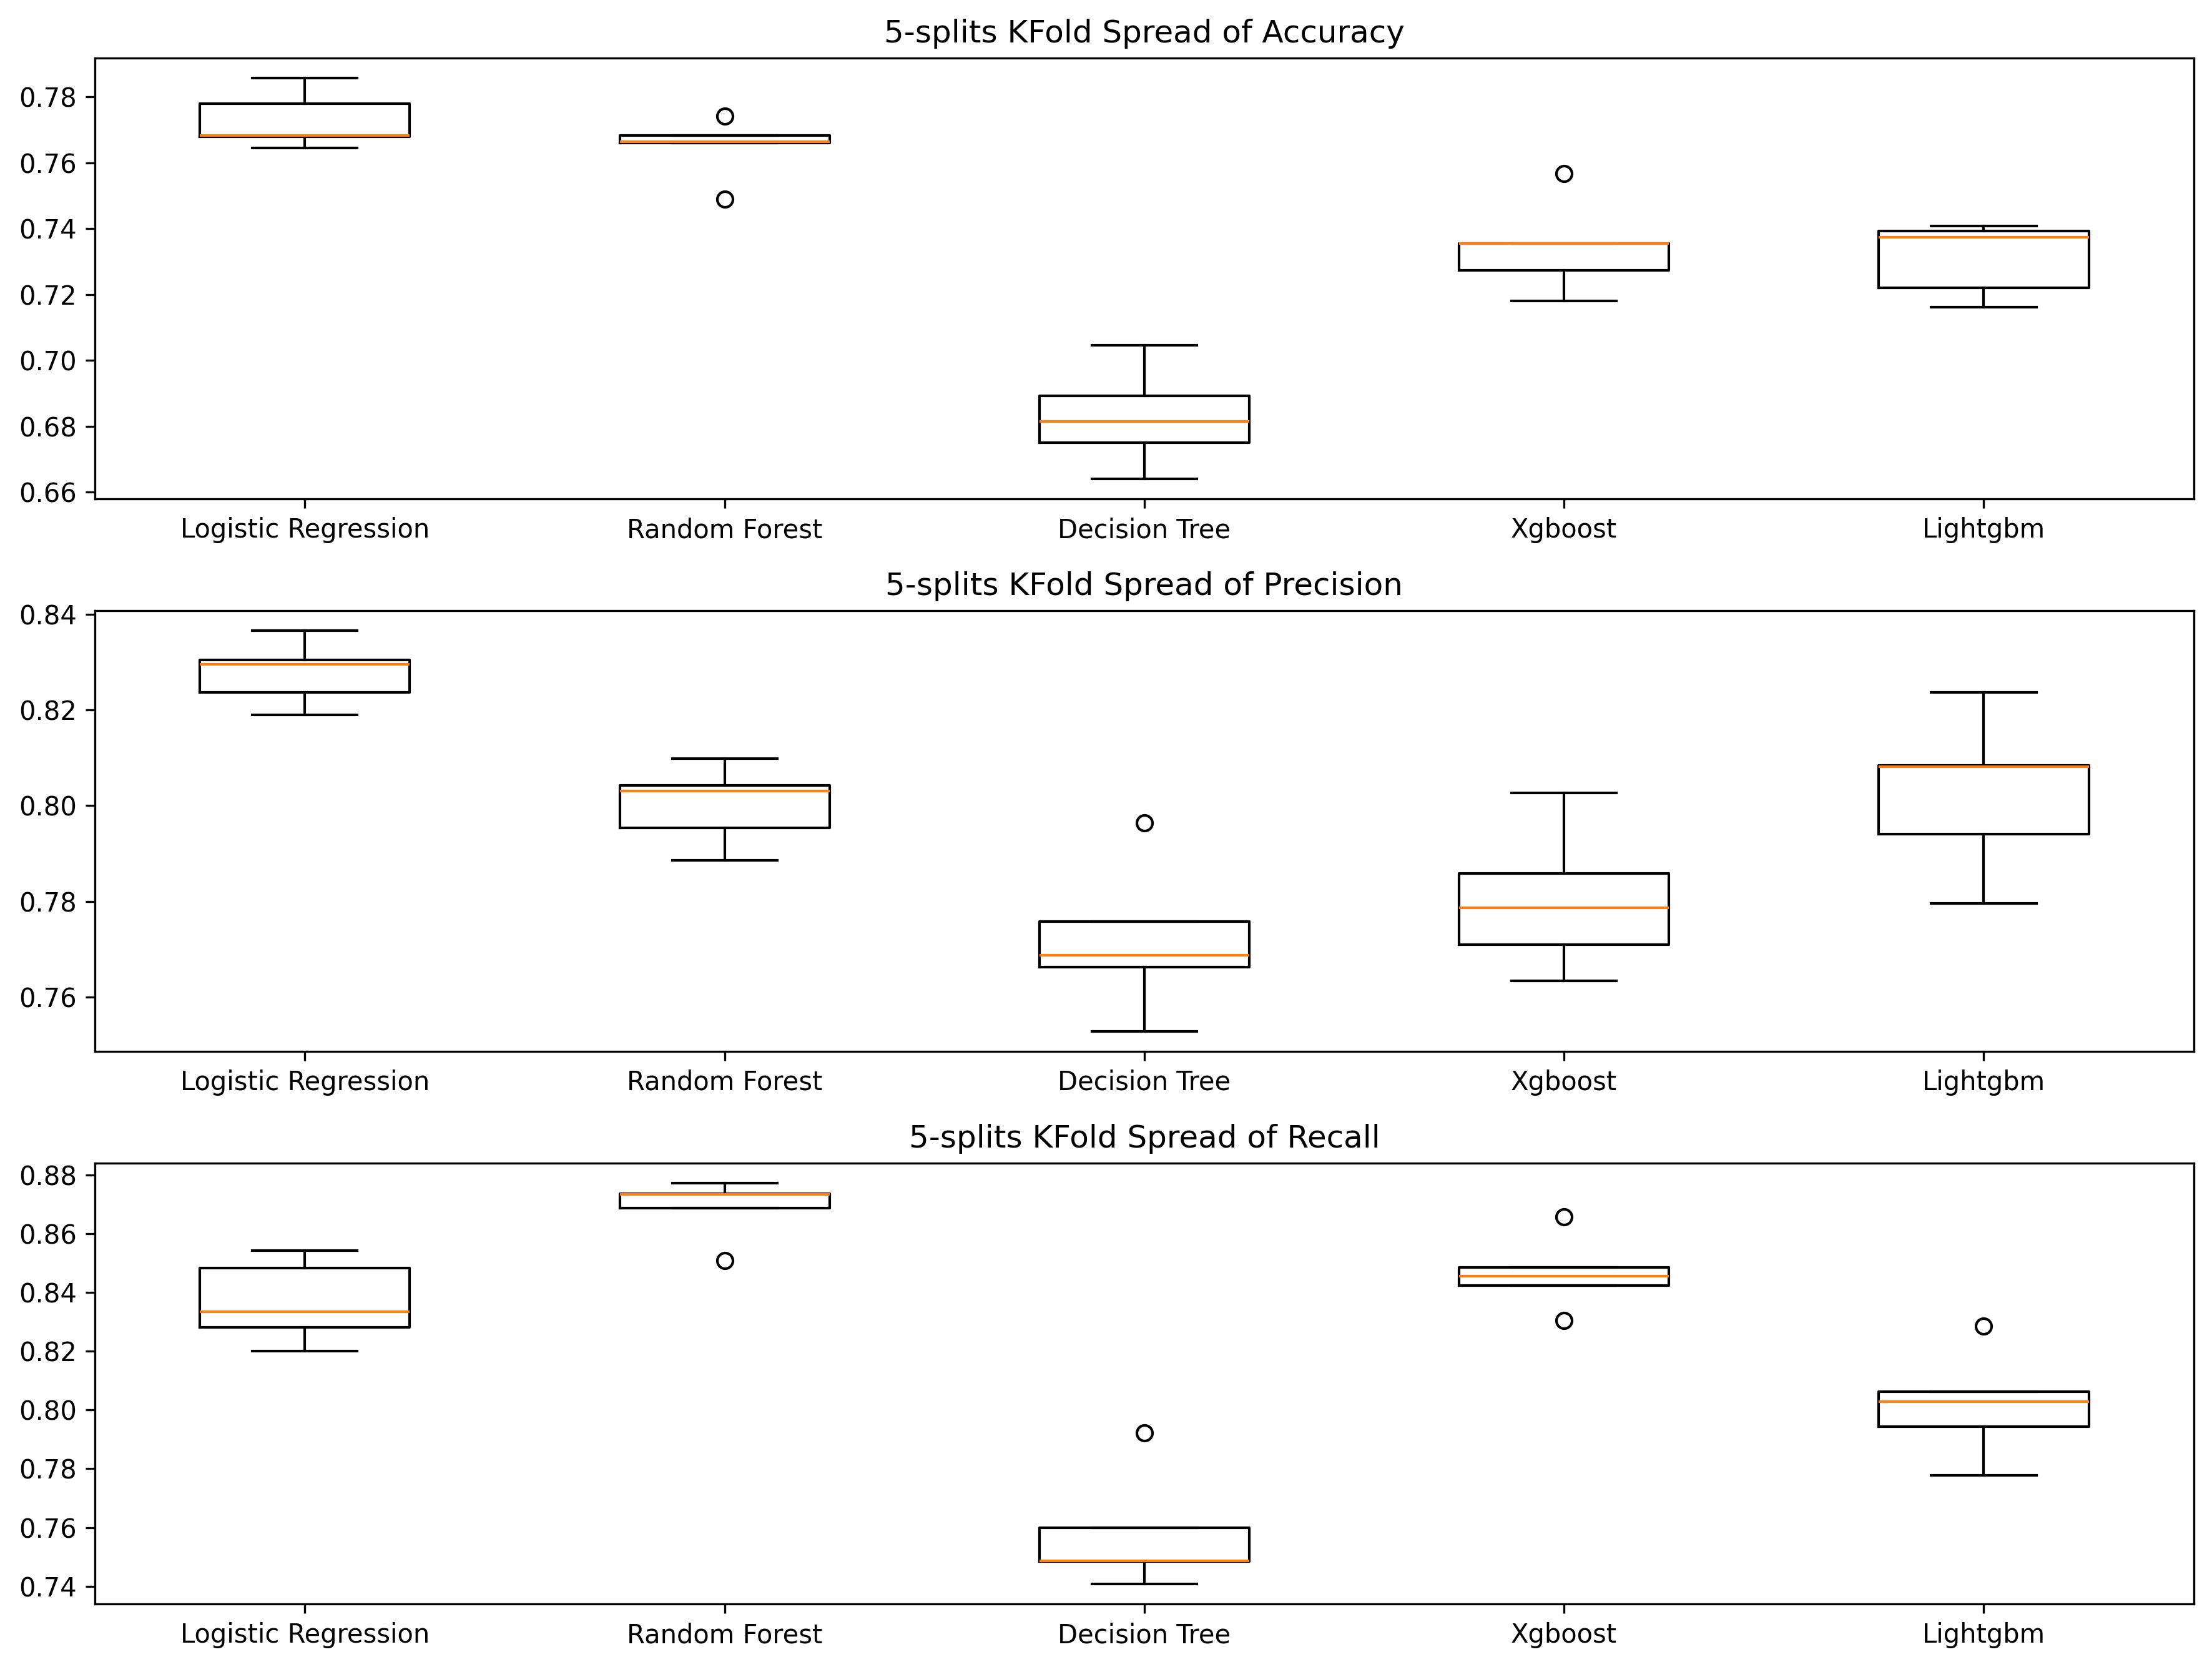

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize = (12,9), dpi = 300)
ax1.boxplot(accuracy_avg, labels = model_name)
ax1.set_title("5-splits KFold Spread of Accuracy")
ax2.boxplot(precision_avg, labels = model_name)
ax2.set_title("5-splits KFold Spread of Precision")
ax3.boxplot(recall_avg, labels = model_name)
ax3.set_title("5-splits KFold Spread of Recall")
plt.tight_layout()
plt.show()

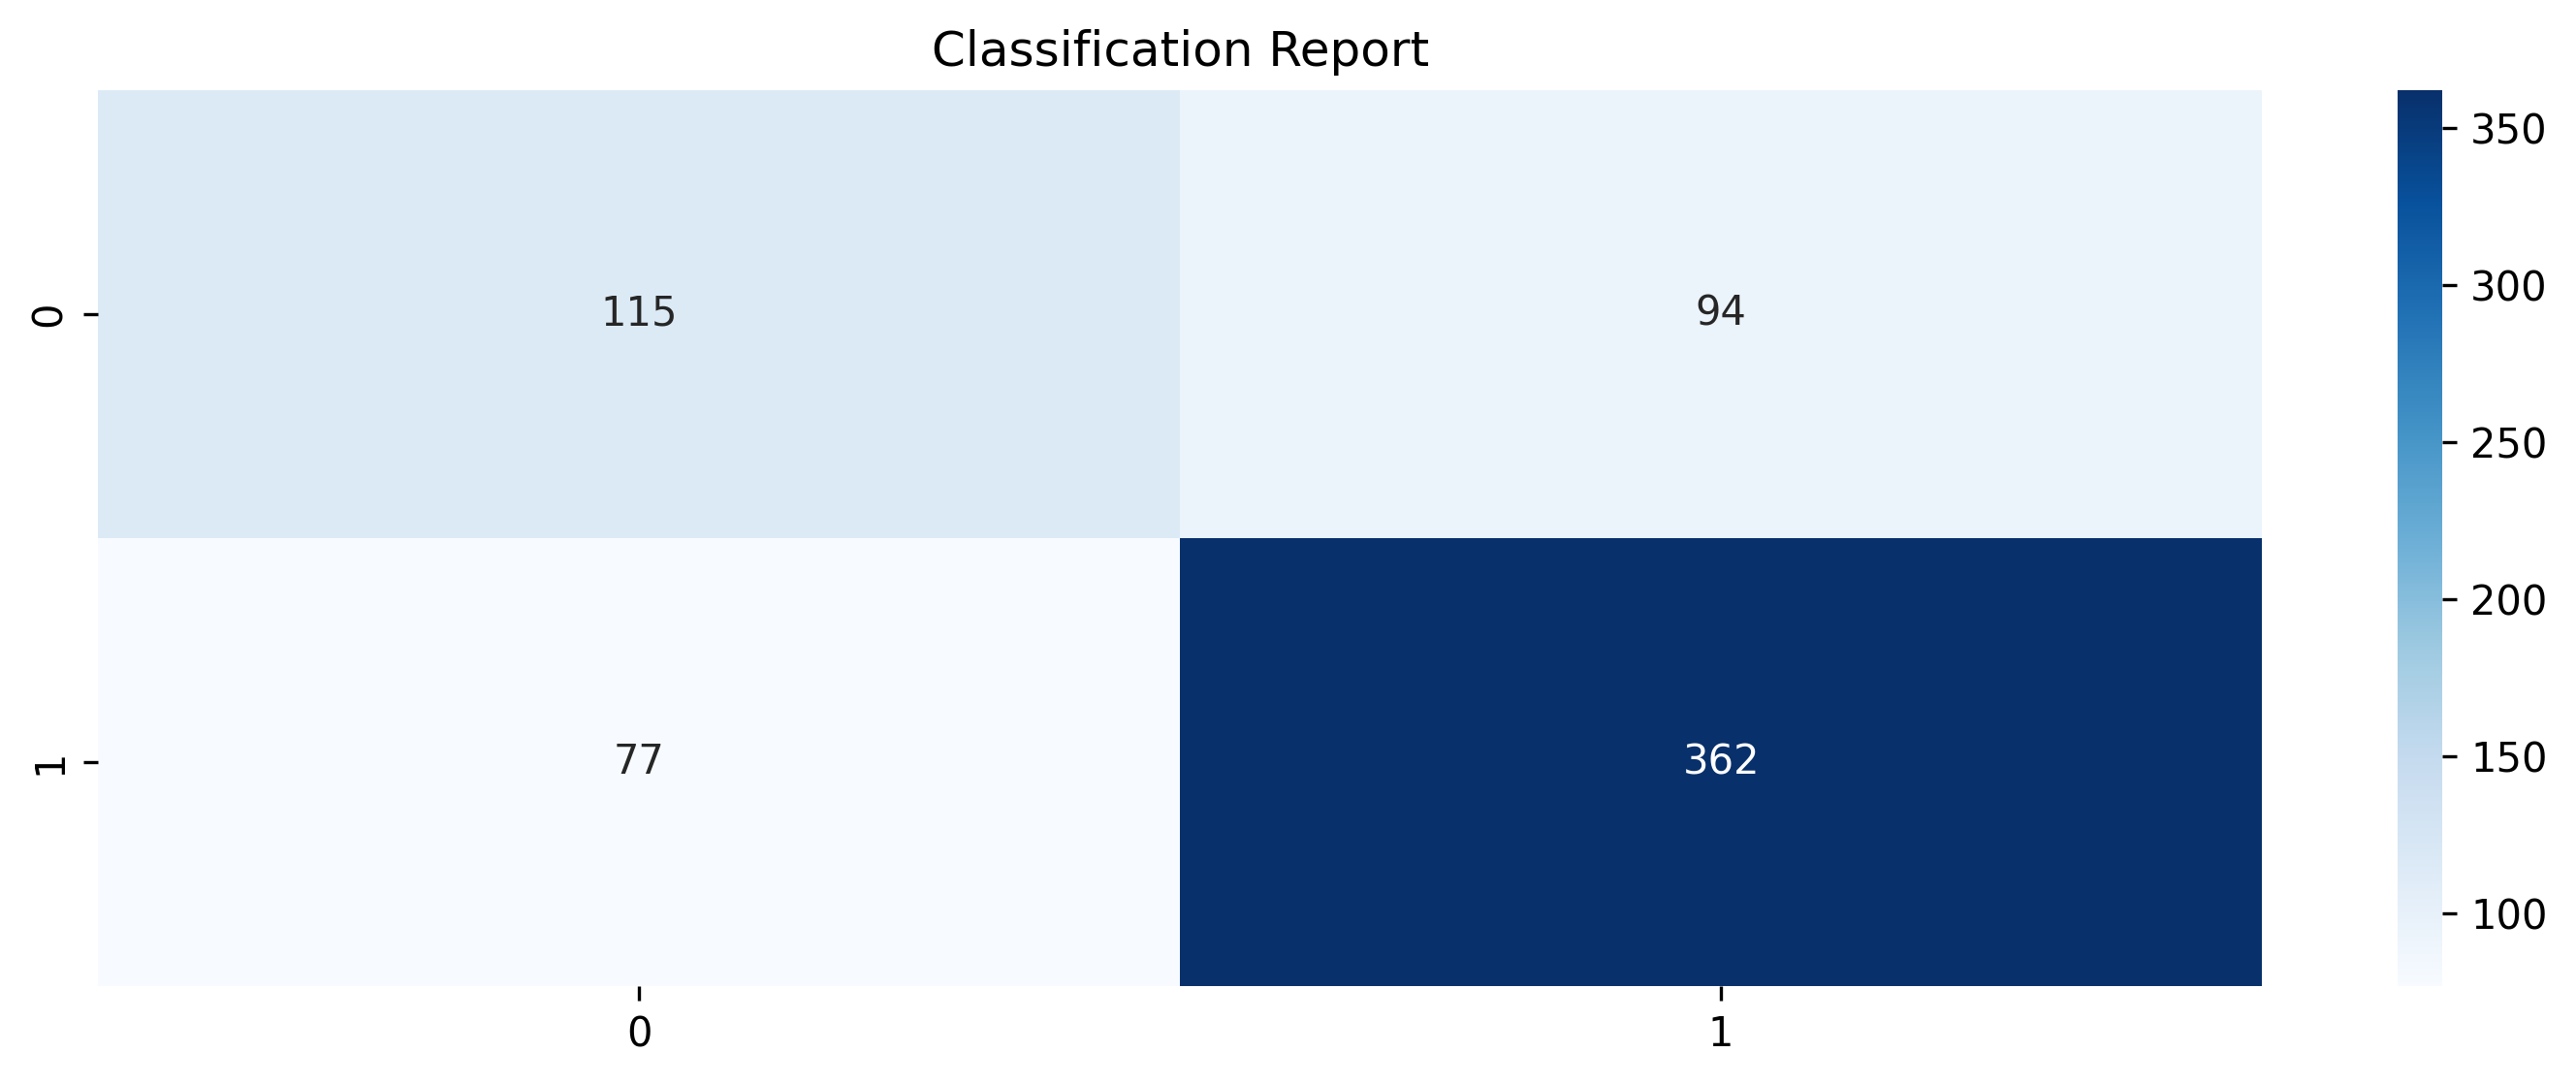

              precision    recall  f1-score   support

           0       0.60      0.55      0.57       209
           1       0.79      0.82      0.81       439

    accuracy                           0.74       648
   macro avg       0.70      0.69      0.69       648
weighted avg       0.73      0.74      0.73       648



In [ ]:
import joblib
import s3fs

model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
model = RandomForestClassifier(n_estimators = 250, max_depth = 20, min_samples_leaf = 2, random_state = 42, class_weight = 'balanced')
pipeline = make_pipeline(scaler, model)
pipeline.fit(X_train, y_train)

fs = s3fs.S3FileSystem()
model_path = "s3://sales-data-analytics-portfolio-2026/predictive_models/churn_model.joblib"

with fs.open(model_path, "wb") as f:
    joblib.dump(pipeline, f)

with fs.open(model_path, "rb") as f:
    loaded_model = joblib.load(f)

y_pred = loaded_model.predict(X_test)
y_proba = loaded_model.predict_proba(X_test)[:,1]

c_matrix = confusion_matrix(y_test, y_pred)

# Creating predictions table in Database
pred_df = pd.DataFrame({
    "CustomerID" : ids_test,
    "ActualChurn": y_test,
    "PredictedProbability": y_proba,
    "PredictedLabel": y_pred
})


plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(c_matrix, cmap='Blues', annot = True, fmt = 'g')
plt.title("Classification Report")
plt.show()

print(classification_report(y_test, y_pred))

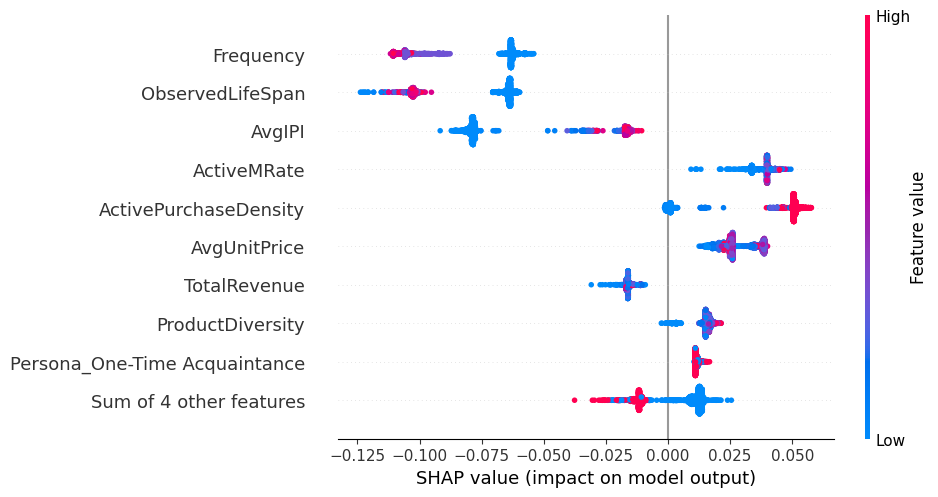

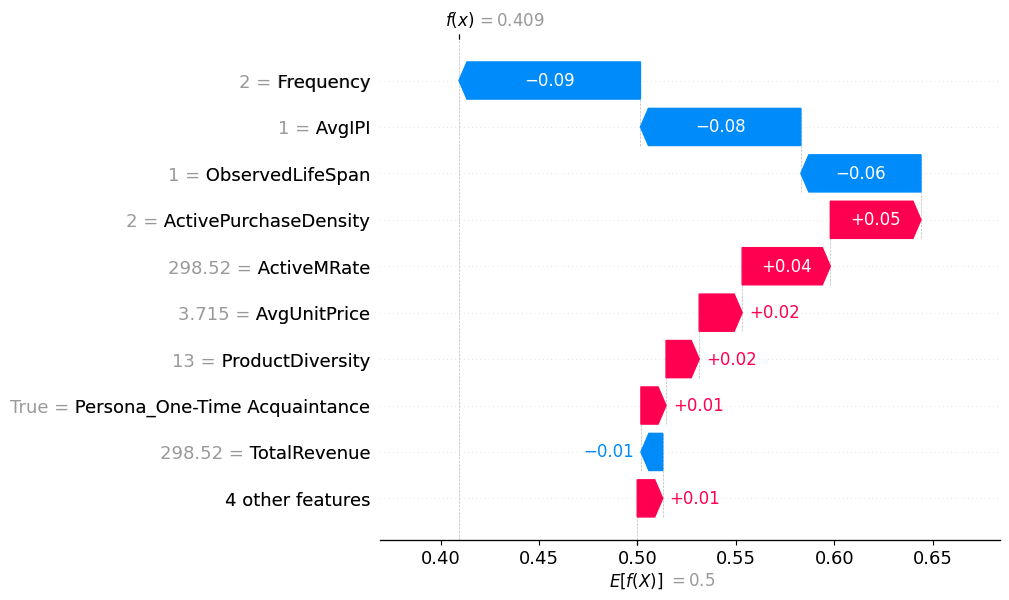

In [ ]:

import matplotlib.pyplot as plt
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)  # or X_test

shap_values_class1 = shap_values[:, :, 1]

shap.plots.beeswarm(shap_values_class1, max_display=10)

plt.clf()

shap.plots.waterfall(shap_values_class1[0], max_display=10)

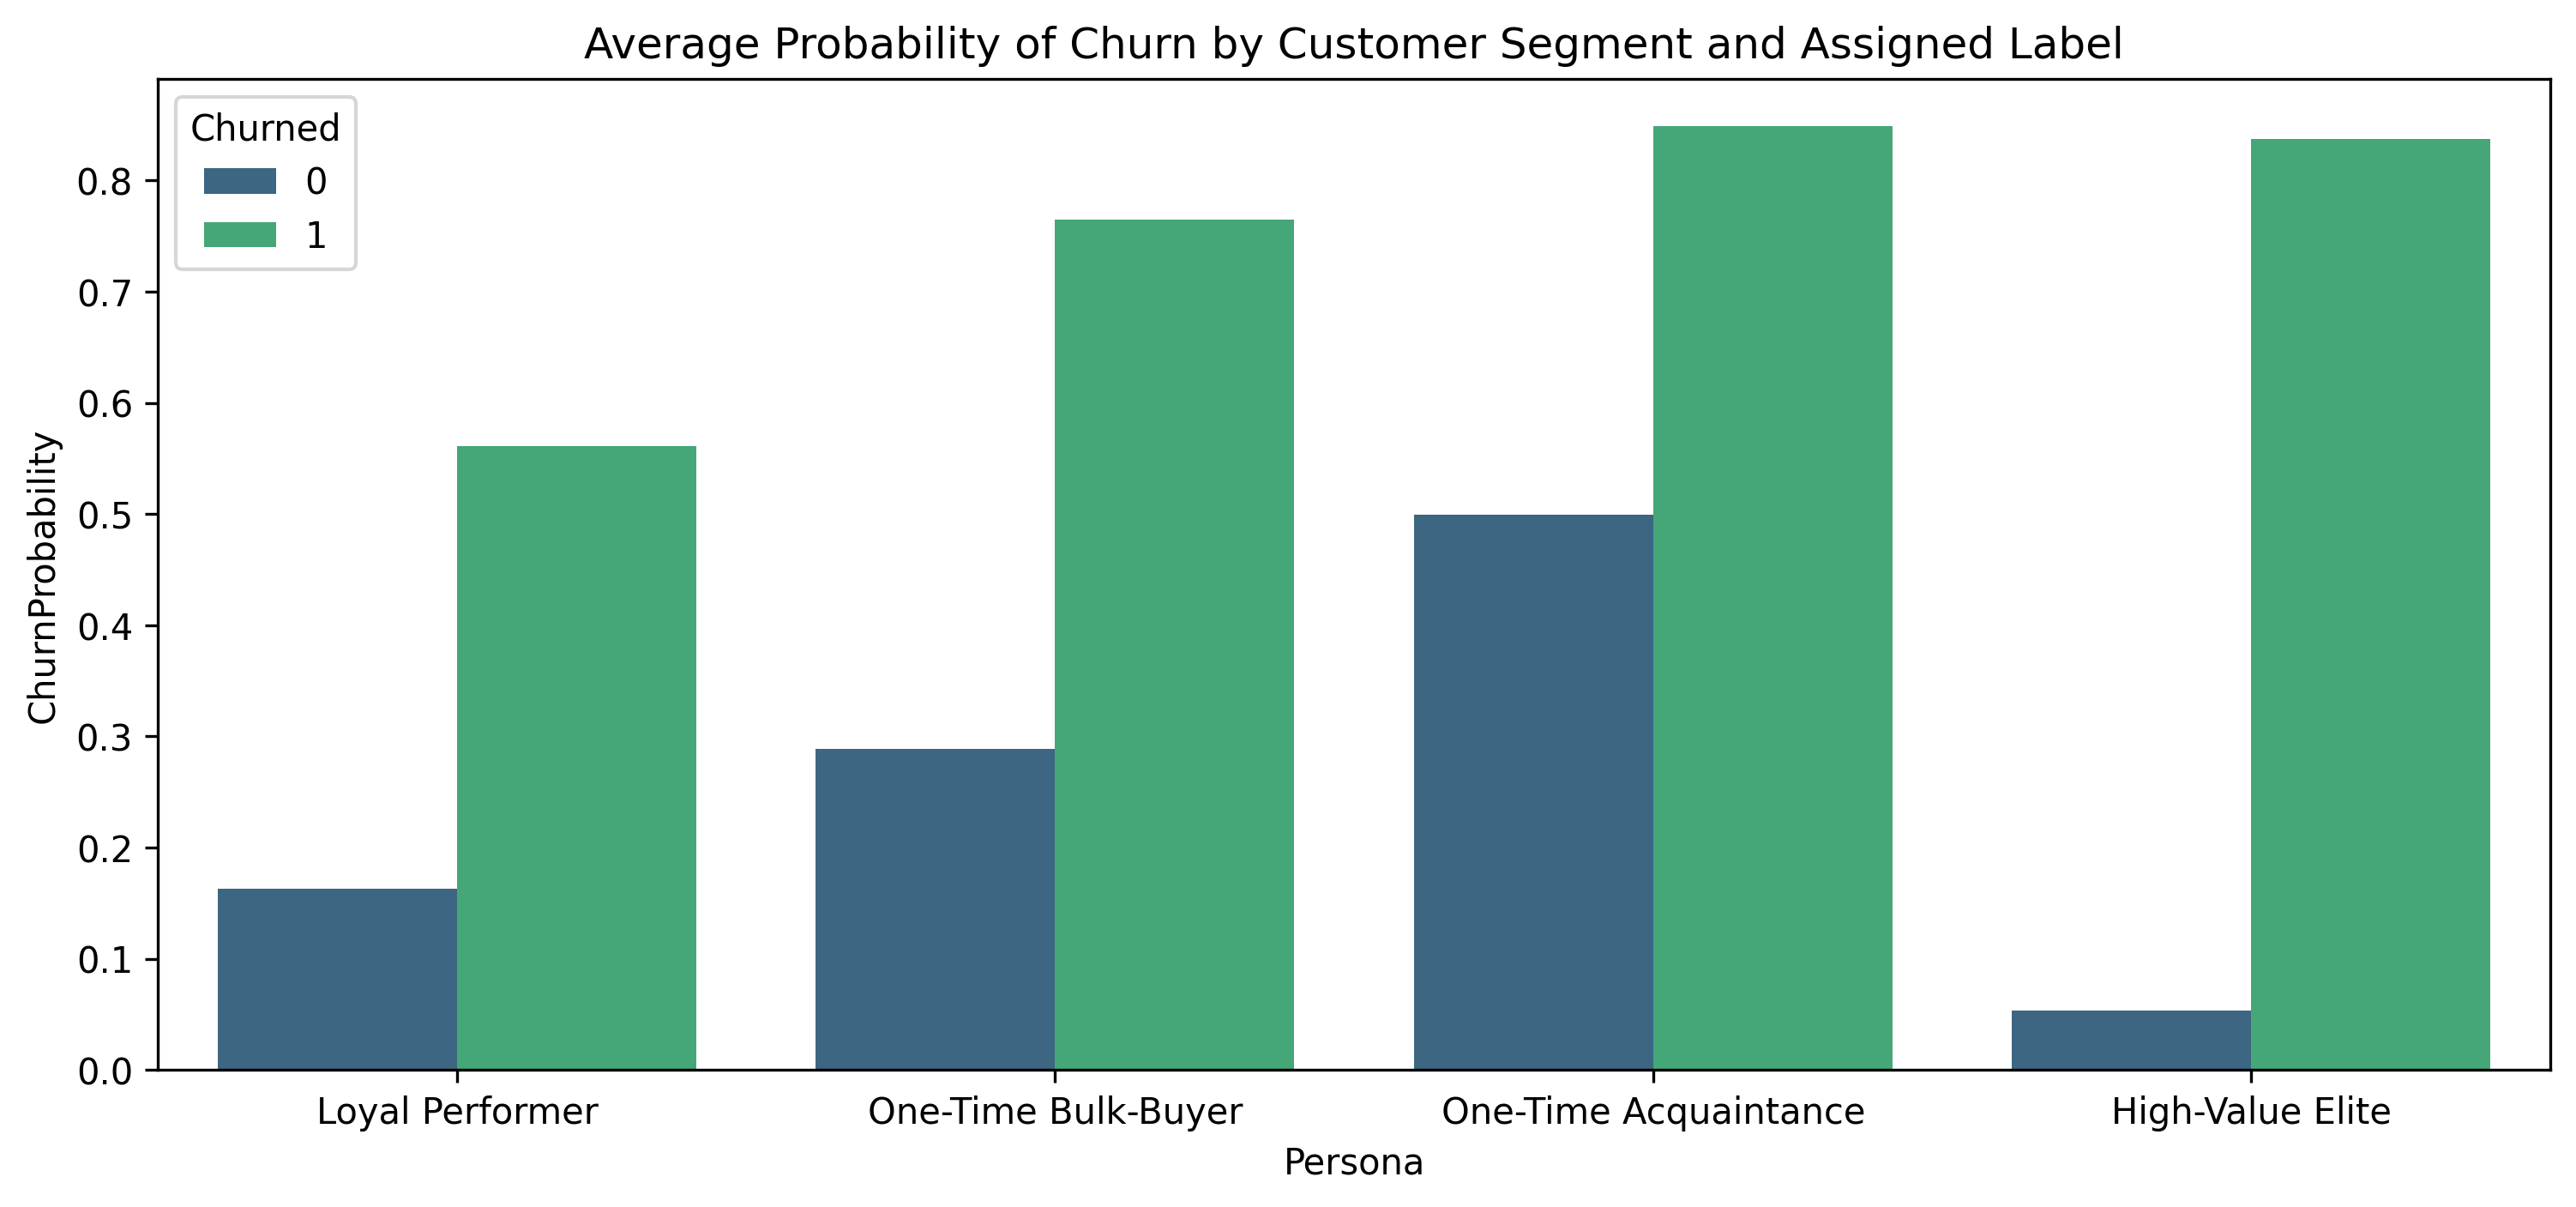

In [49]:
# Predicting churn for entire dataset
X_all = df.drop(cols_to_drop, axis = 1)
X_all.drop("CustomerID", inplace = True, axis = 1)
X_all = pd.get_dummies(X_all, drop_first = True)

churn_label = loaded_model.predict(X_all)
churn_prob = loaded_model.predict_proba(X_all)[:,1]

churn_df = df.copy() #.drop(cols_to_drop, axis = 1)

churn_df["ChurnProbability"] = churn_prob
churn_df["ChurnLabel"] = churn_label

plt.figure(figsize = (12,5), dpi = 300)
sns.barplot(data = churn_df, x = "Persona", y = "ChurnProbability", hue = "Churned", errorbar = None, palette = "viridis")
plt.title("Average Probability of Churn by Customer Segment and Assigned Label")
plt.show()